# Analys — rolling horizon-körning
Läser direkt från CSV-filer, kräver ingen `network.nc`.

In [1]:
import sys, yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

LABEL = 'run18_rolling_baseline'   # ← ändra här
RES   = ROOT / 'results' / LABEL
PROC  = ROOT / 'data' / 'processed'

plt.rcParams['figure.figsize'] = (15, 4)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

ZONES = ['SE-N', 'SE-S', 'NO-N', 'NO-S', 'DK', 'FI']

with open(ROOT / 'config' / 'zones.yaml') as f:
    cfg = yaml.safe_load(f)
with open(ROOT / 'config' / 'hydro_params.yaml') as f:
    hydro_params = yaml.safe_load(f)

In [2]:
dispatch  = pd.read_csv(RES / 'dispatch_generators.csv', index_col=0, parse_dates=True)
hydro_d   = pd.read_csv(RES / 'dispatch_hydro.csv',      index_col=0, parse_dates=True)
soc       = pd.read_csv(RES / 'hydro_soc.csv',           index_col=0, parse_dates=True)
spill     = pd.read_csv(RES / 'hydro_spill.csv',         index_col=0, parse_dates=True)
flows     = pd.read_csv(RES / 'flows.csv',               index_col=0, parse_dates=True)
prices    = pd.read_csv(RES / 'prices.csv',              index_col=0, parse_dates=True)

mkt_prices = pd.read_parquet(PROC / 'market_prices.parquet')
mkt_prices.index = pd.to_datetime(mkt_prices.index, utc=True).tz_localize(None)
mkt_price = mkt_prices['DE-LU']

load_raw = pd.read_parquet(PROC / 'load.parquet')
load_raw.index = pd.to_datetime(load_raw.index, utc=True).tz_localize(None)
load = load_raw.reindex(dispatch.index)

dt_h = (dispatch.index[1] - dispatch.index[0]).total_seconds() / 3600

# Marknadsanslutningar per zon från config
_mkt_by_zone = {}
for name, zone, _, _ in cfg.get('market_connections', []):
    _mkt_by_zone.setdefault(zone, []).append(name)

def zone_market(zone):
    cols = [c for c in _mkt_by_zone.get(zone, []) if c in dispatch.columns]
    return dispatch[cols].sum(axis=1) if cols else pd.Series(0.0, index=dispatch.index)

print(f'Körning: {LABEL}')
print(f'Tidssteg: {len(dispatch)}  ({dispatch.index[0].date()} – {dispatch.index[-1].date()})')
print(f'Slack totalt: {dispatch.filter(like="slack").sum().sum()/1e3:.1f} GWh  (bör vara ~0)')

Körning: run18_rolling_baseline
Tidssteg: 8768  (2023-01-01 – 2025-12-31)
Slack totalt: 0.0 GWh  (bör vara ~0)


## Priser

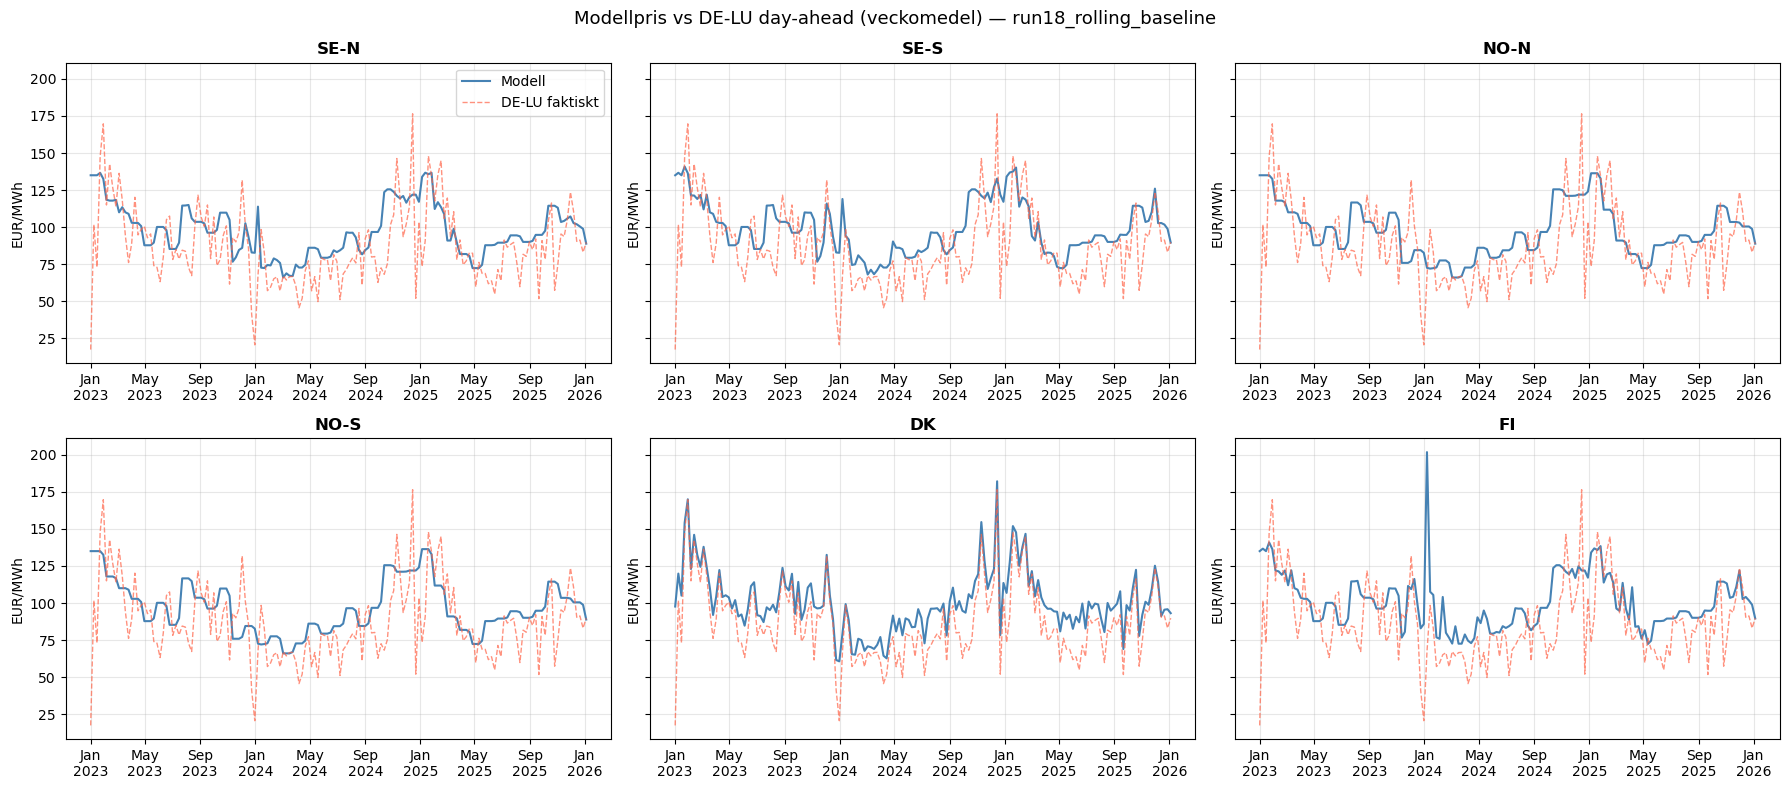

In [3]:
mkt_w = mkt_price.resample('W').mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
for ax, zone in zip(axes.flat, ZONES):
    p = prices[zone].resample('W').mean()
    ax.plot(p.index, p.values, lw=1.5, color='steelblue', label='Modell')
    ax.plot(mkt_w.index, mkt_w.values, lw=1, color='tomato', ls='--', alpha=0.7, label='DE-LU faktiskt')
    ax.set_title(zone, fontweight='bold')
    ax.set_ylabel('EUR/MWh')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[0, 0].legend()
plt.suptitle(f'Modellpris vs DE-LU day-ahead (veckomedel) — {LABEL}', fontsize=13)
plt.tight_layout()

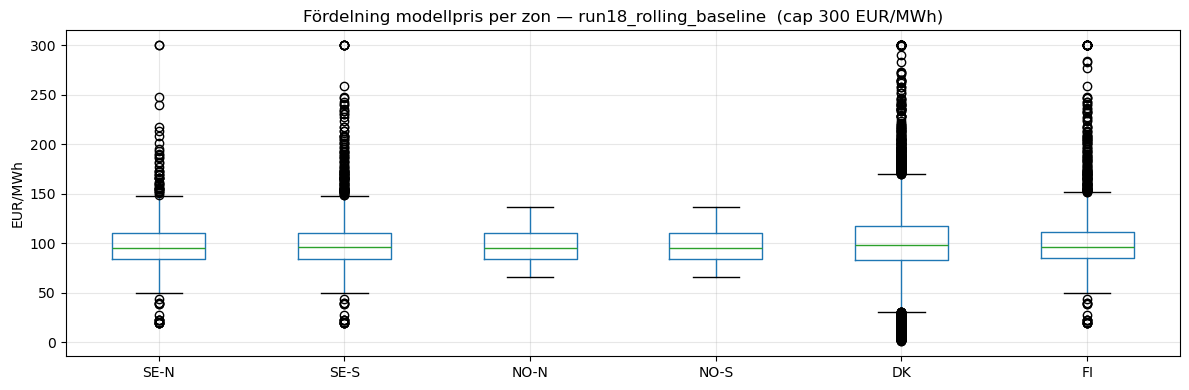

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
prices[ZONES].clip(upper=300).boxplot(ax=ax)
ax.set_ylabel('EUR/MWh')
ax.set_title(f'Fördelning modellpris per zon — {LABEL}  (cap 300 EUR/MWh)')
plt.tight_layout()

In [5]:
YEARS = [2023, 2024, 2025]
EXT   = list(mkt_prices.columns)

header = f'{"":10}' + ''.join(f'{y:>9}' for y in YEARS)
print(header)
print('-' * len(header))

print('-- Modellzoner (skuggpris, EUR/MWh) --')
for zone in ZONES:
    row = f'{zone:<10}'
    for y in YEARS:
        row += f'{prices[zone][prices.index.year == y].mean():>8.1f} '
    print(row)

print('-- Externa marknader (day-ahead, EUR/MWh) --')
for ext in EXT:
    row = f'{ext:<10}'
    for y in YEARS:
        row += f'{mkt_prices[ext][mkt_prices.index.year == y].mean():>8.1f} '
    print(row)

               2023     2024     2025
-------------------------------------
-- Modellzoner (skuggpris, EUR/MWh) --
SE-N         102.7     92.0     97.8 
SE-S         104.1     93.6     98.9 
NO-N         101.9     91.6     97.2 
NO-S         101.9     91.6     97.2 
DK           106.6     92.8    102.7 
FI           104.7     96.9    100.2 
-- Externa marknader (day-ahead, EUR/MWh) --
DE-LU         95.2     78.5     89.3 
EE            90.8     87.3     80.4 
LT            94.4     87.3     85.3 
PL           111.7     96.3    104.3 
NL            95.8     77.3     86.8 
GB           110.7     85.3     95.4 


## SOC — reservoarnivåer

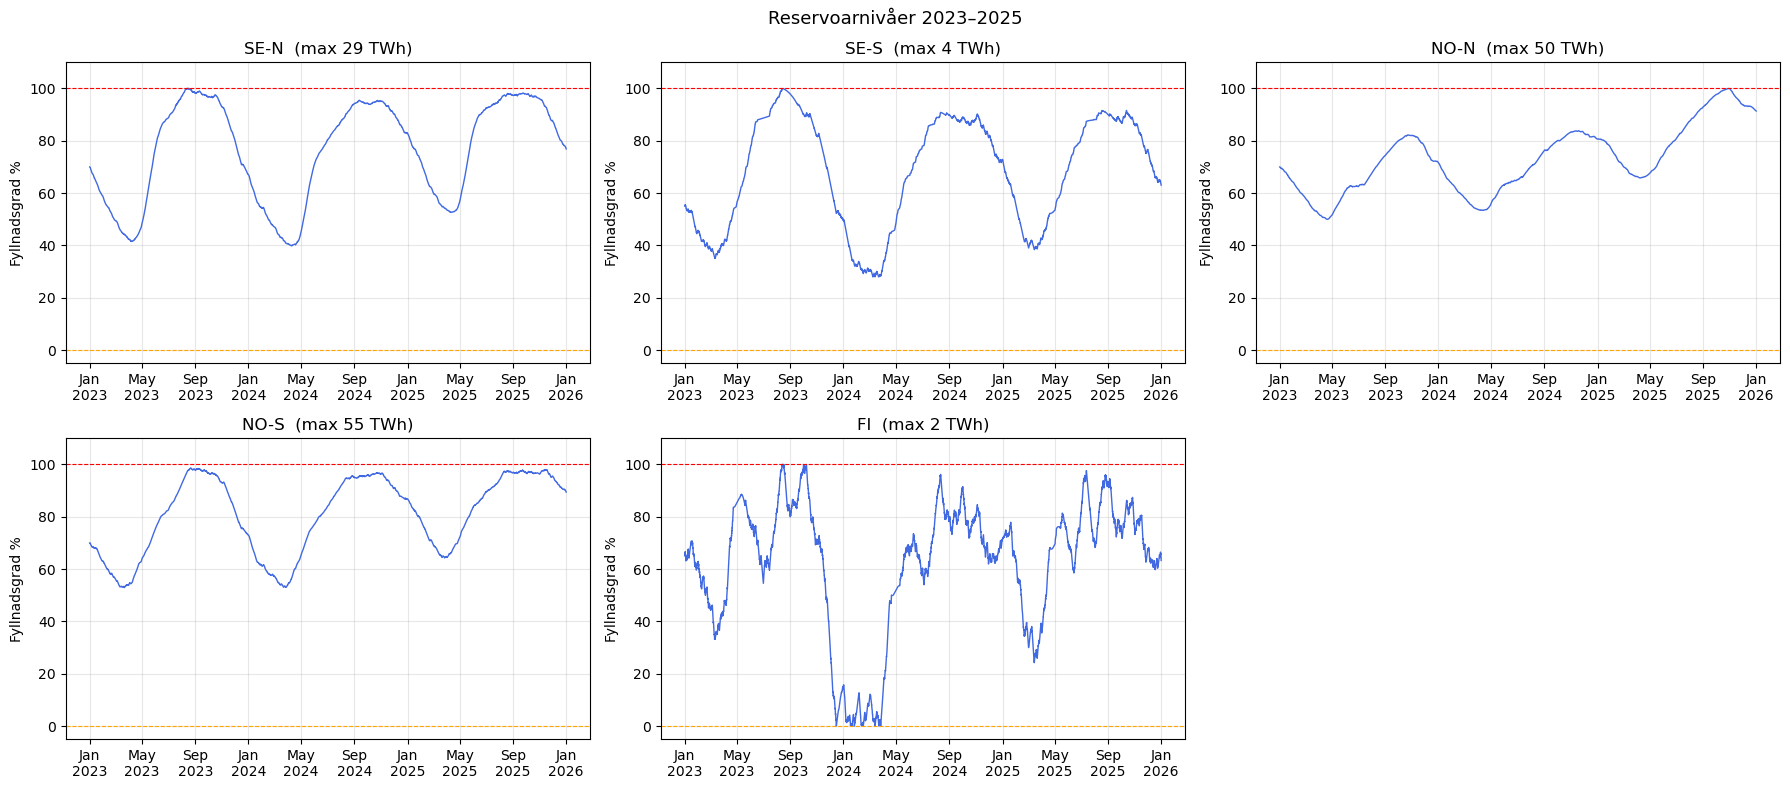

In [6]:
hydro_zones = [z for z in ZONES if cfg['zones'][z].get('hydro_p_nom_mw', 0) > 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, zone in zip(axes.flat, hydro_zones):
    p_nom = cfg['zones'][zone]['hydro_p_nom_mw']
    max_h = cfg['zones'][zone]['hydro_max_hours']
    col   = f'{zone} hydro'
    if col in soc.columns:
        soc_pct = soc[col] / (p_nom * max_h) * 100
        ax.plot(soc_pct.index, soc_pct.values, lw=1, color='royalblue')
        ax.axhline(100, color='red',    ls='--', lw=0.8, label='Max')
        ax.axhline(0,   color='orange', ls='--', lw=0.8, label='Min')
        ax.set_ylim(-5, 110)
        ax.set_title(f'{zone}  (max {p_nom*max_h/1e6:.0f} TWh)')
        ax.set_ylabel('Fyllnadsgrad %')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

for ax in axes.flat[len(hydro_zones):]:
    ax.set_visible(False)

plt.suptitle('Reservoarnivåer 2023–2025', fontsize=13)
plt.tight_layout()

## Inflöde (modellerat)

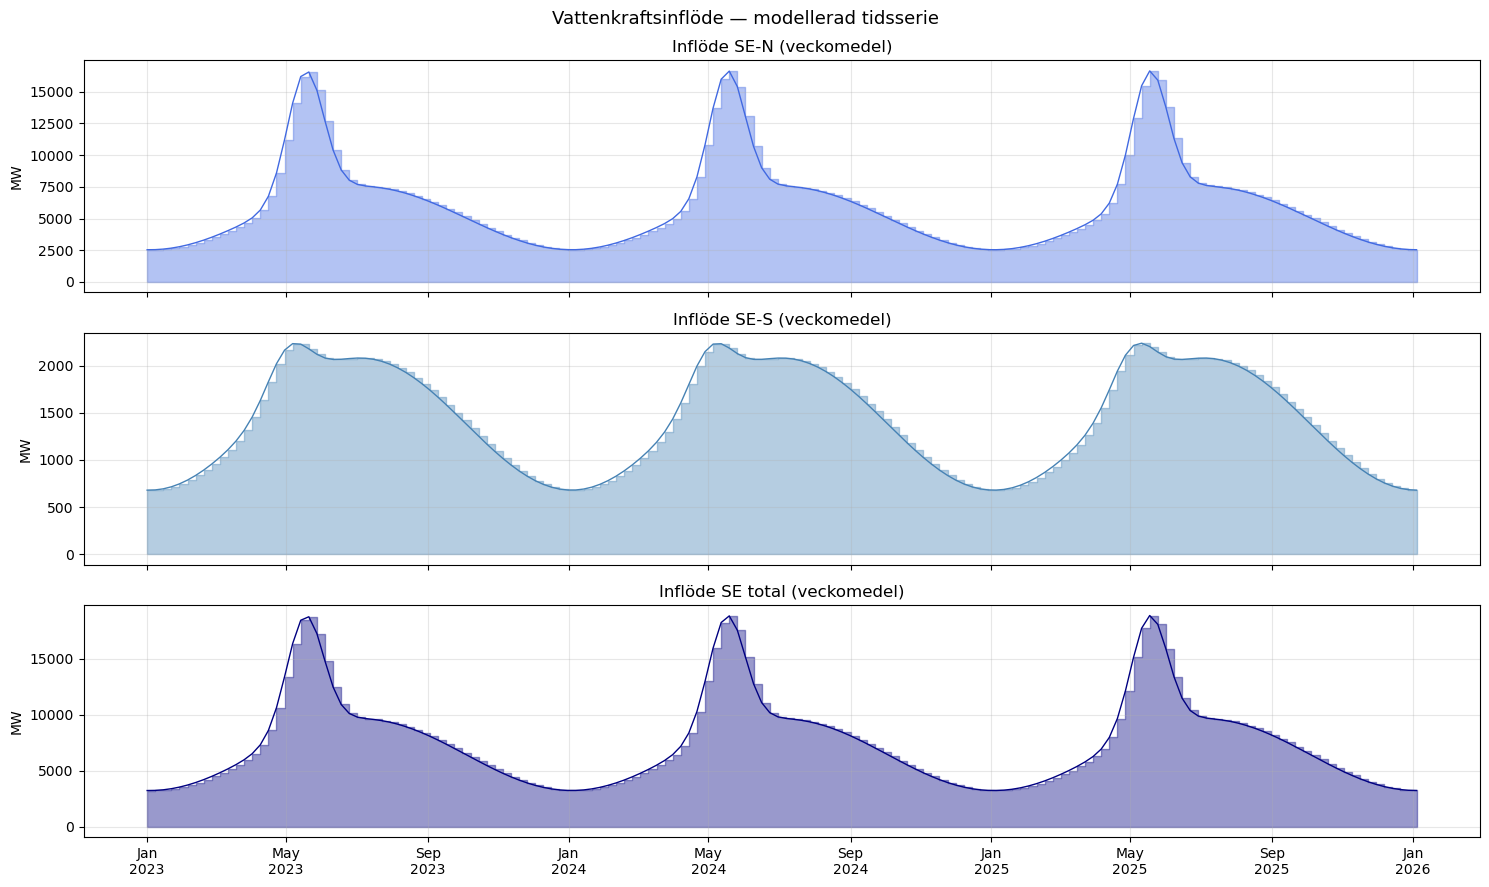

In [7]:
from nordpsa.hydro import inflow_timeseries

snapshots = dispatch.index
inflow = {
    zone: inflow_timeseries(hydro_params[zone], snapshots)
    for zone in hydro_zones
    if zone in hydro_params
}

sen    = inflow.get('SE-N', pd.Series(0.0, index=snapshots)).resample('W').mean()
ses    = inflow.get('SE-S', pd.Series(0.0, index=snapshots)).resample('W').mean()
se_tot = sen + ses

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for ax, data, label, color in zip(
    axes,
    [sen, ses, se_tot],
    ['SE-N', 'SE-S', 'SE total'],
    ['royalblue', 'steelblue', 'navy'],
):
    ax.fill_between(data.index, data.values, alpha=0.4, color=color, step='post')
    ax.plot(data.index, data.values, lw=1, color=color)
    ax.set_ylabel('MW')
    ax.set_title(f'Inflöde {label} (veckomedel)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.suptitle('Vattenkraftsinflöde — modellerad tidsserie', fontsize=13)
plt.tight_layout()

## Spill

In [8]:
total_spill_twh = spill.sum() * dt_h / 1e6
print('Total spill per zon (TWh):')
any_spill = False
for col, val in total_spill_twh.items():
    if val > 0.001:
        print(f'  {col}: {val:.3f} TWh')
        any_spill = True
if not any_spill:
    print('  Inget spill')

Total spill per zon (TWh):
  Inget spill


## Dispatch per zon

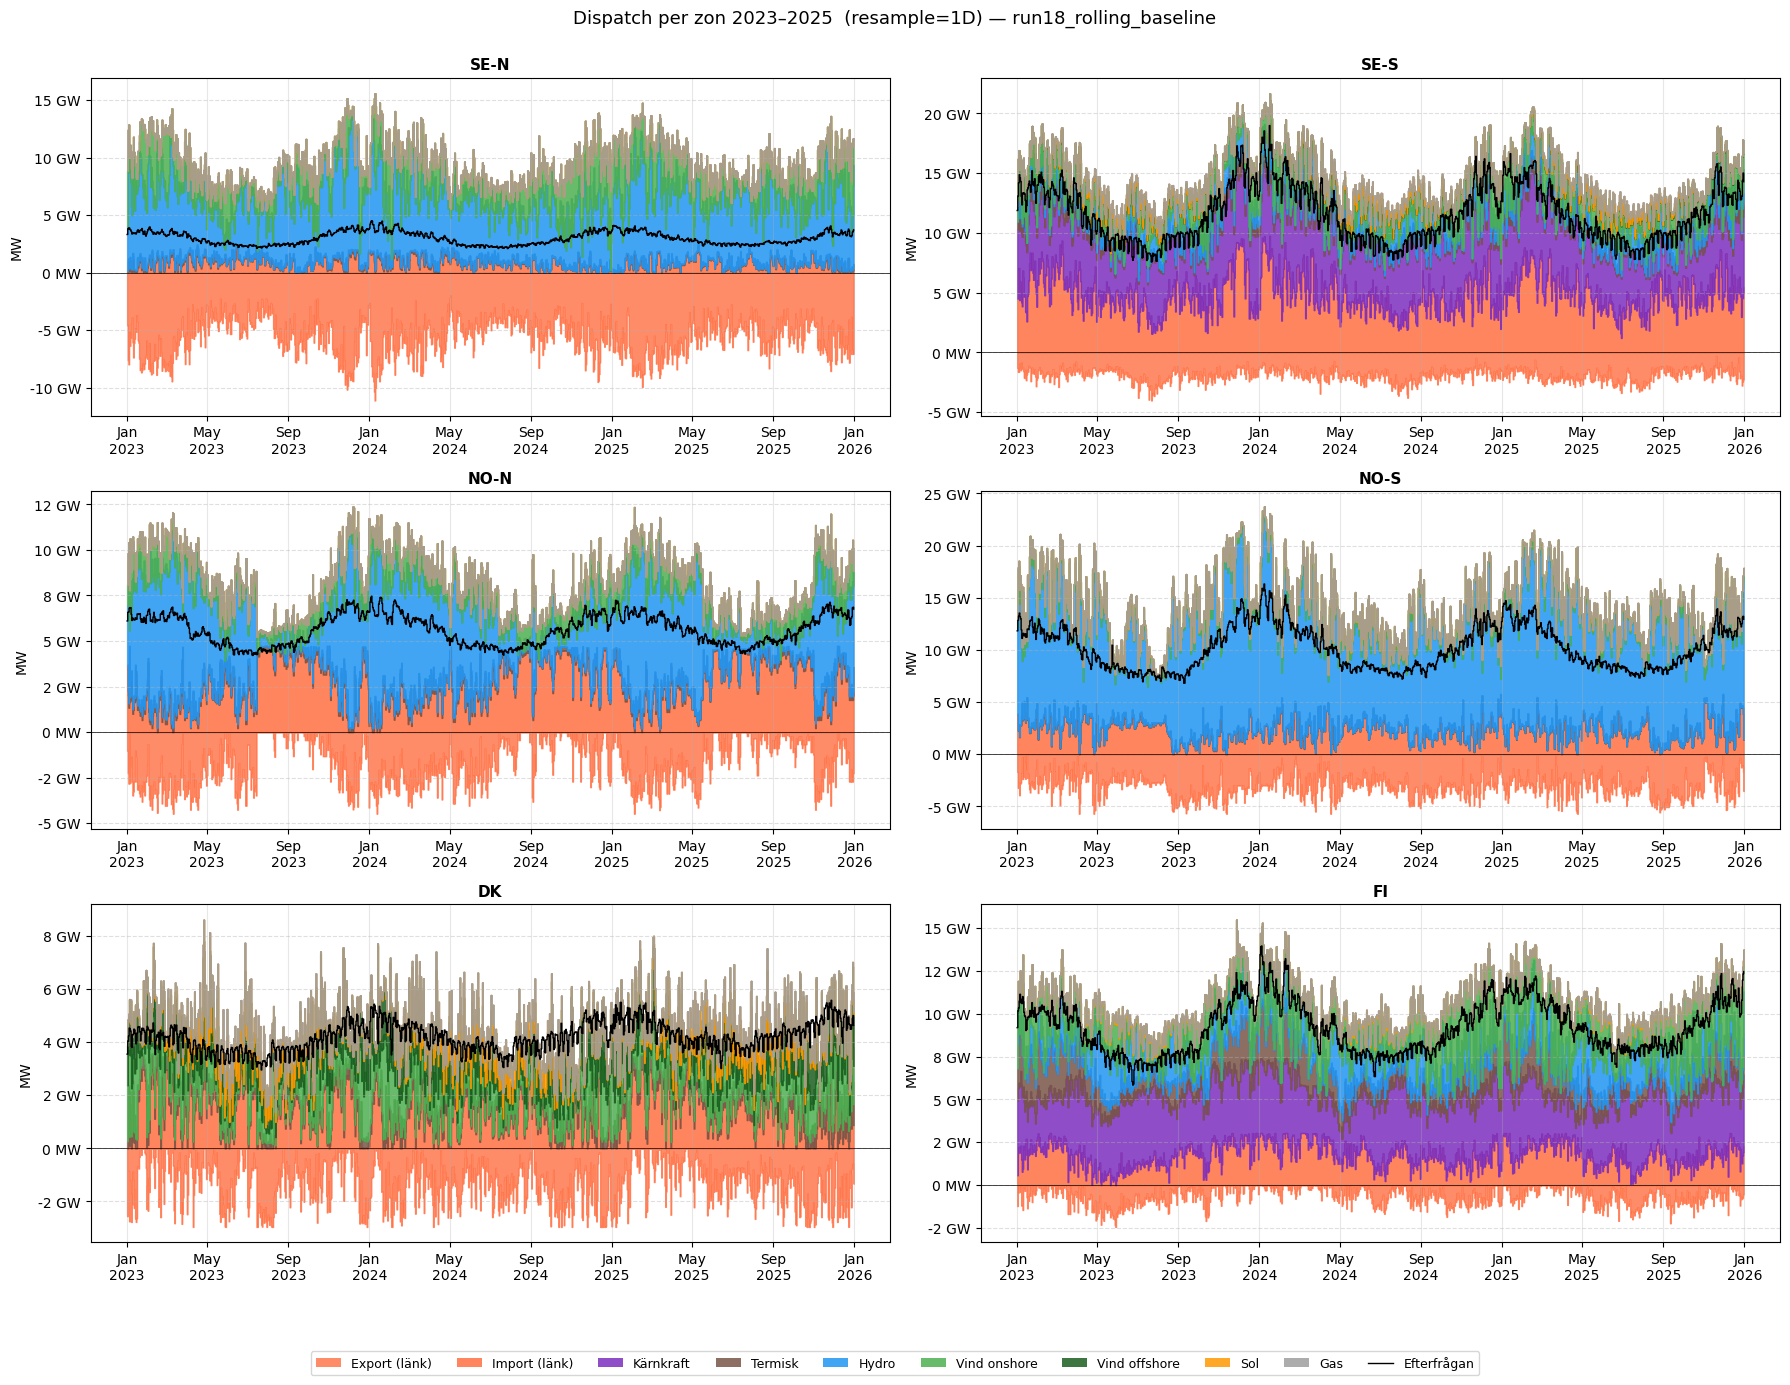

In [9]:
from scripts.plot_dispatch import build_zone_df, plot_zone, make_legend

RESAMPLE = '1D'   # None = rådata, '1D' = dag, '7D' = vecka
_data = dict(gen=dispatch, hydro=hydro_d, flows=flows)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
for ax, zone in zip(axes.flat, ZONES):
    df = build_zone_df(zone, _data, load)
    plot_zone(ax, df, zone, RESAMPLE)

carriers_all = set()
for zone in ZONES:
    carriers_all |= set(build_zone_df(zone, _data, load).columns)
make_legend(fig, carriers_all)

plt.suptitle(f'Dispatch per zon 2023–2025  (resample={RESAMPLE}) — {LABEL}', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])

## NTC-flöden

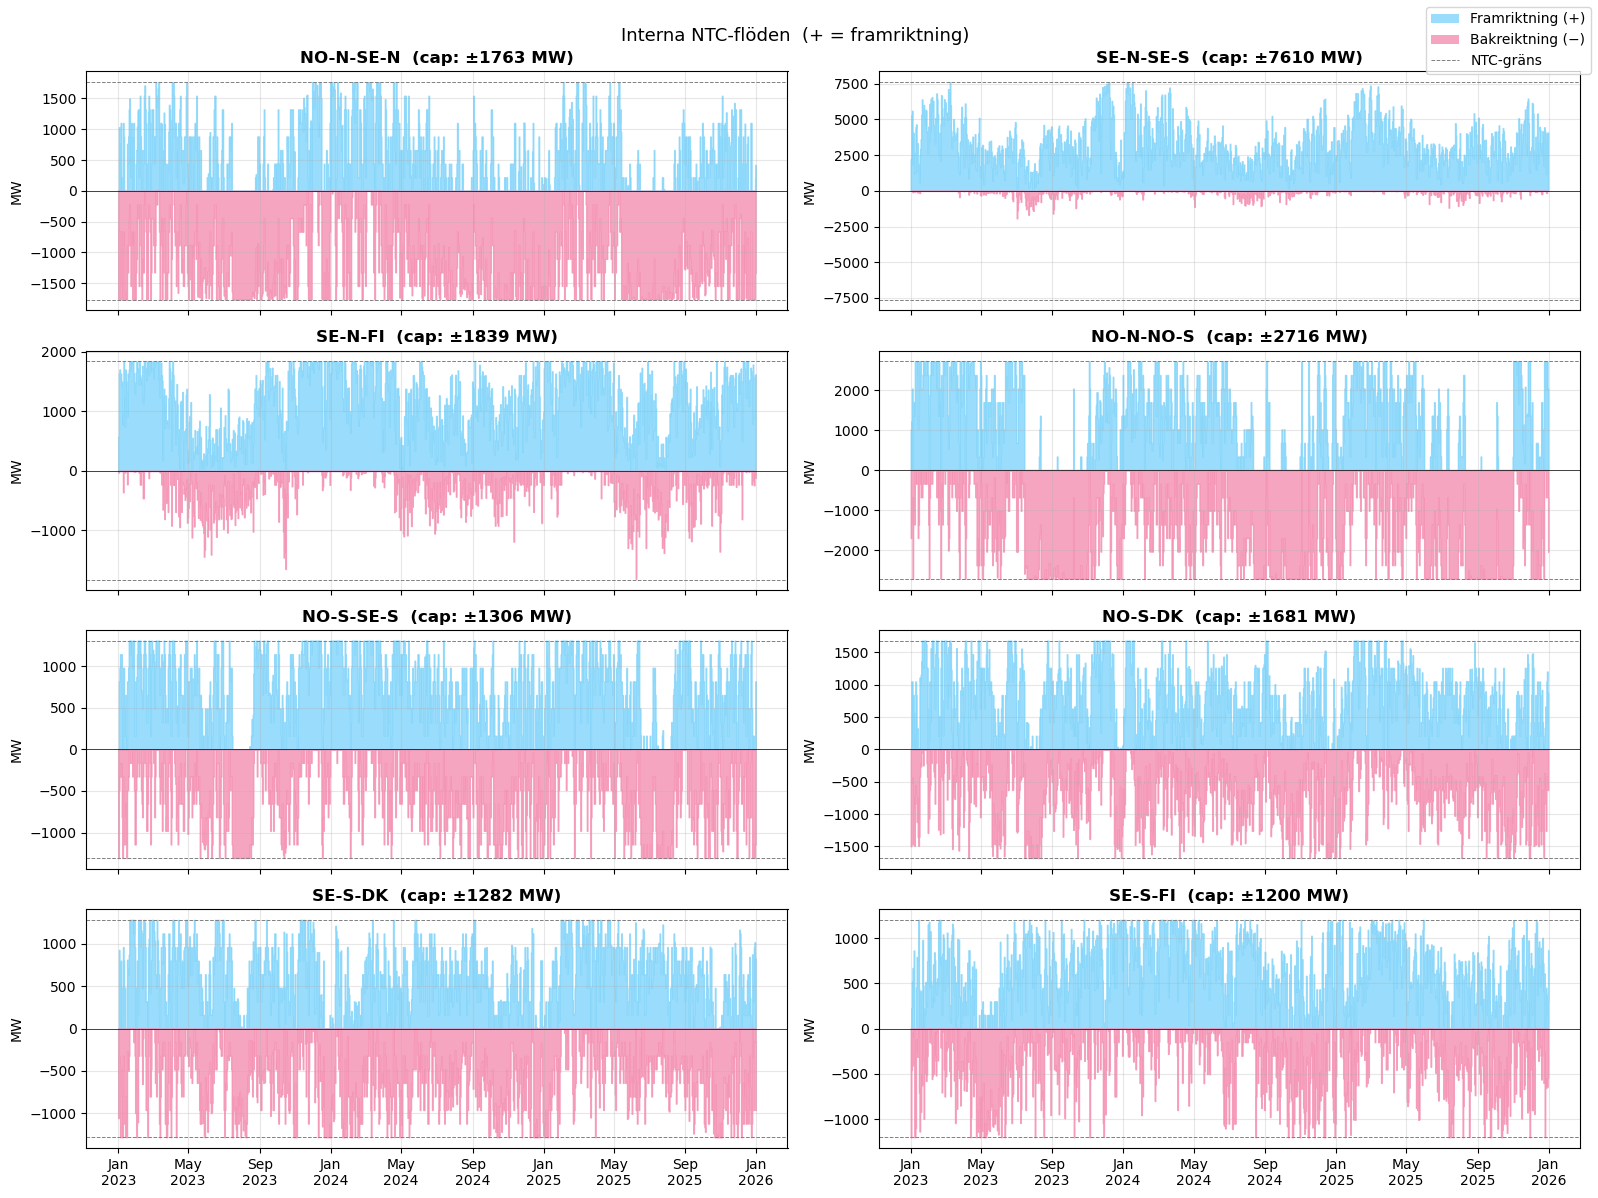

In [10]:
link_caps  = {f'{z0}-{z1}': cap for z0, z1, cap in cfg['links']}
link_names = [l for l in link_caps if l in flows.columns]

ncols = 2
nrows = (len(link_names) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharex=True)

for ax, name in zip(axes.flat, link_names):
    pos = flows[name].clip(lower=0).resample('1D').mean()
    neg = flows[name].clip(upper=0).resample('1D').mean()
    ax.fill_between(pos.index, pos, color='#81D4FA', alpha=0.8, step='post')
    ax.fill_between(neg.index, neg, color='#F48FB1', alpha=0.8, step='post')
    ax.axhline(0, color='black', lw=0.5)
    cap = link_caps[name]
    ax.axhline( cap, color='grey', lw=0.7, ls='--')
    ax.axhline(-cap, color='grey', lw=0.7, ls='--')
    ax.set_title(f'{name}  (cap: ±{cap:.0f} MW)', fontweight='bold')
    ax.set_ylabel('MW')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

for ax in axes.flat[len(link_names):]:
    ax.set_visible(False)

handles = [
    plt.Rectangle((0,0), 1, 1, fc='#81D4FA', alpha=0.8),
    plt.Rectangle((0,0), 1, 1, fc='#F48FB1', alpha=0.8),
    plt.Line2D([0], [0], color='grey', ls='--', lw=0.7),
]
fig.legend(handles, ['Framriktning (+)', 'Bakreiktning (−)', 'NTC-gräns'], loc='upper right')
plt.suptitle('Interna NTC-flöden  (+ = framriktning)', fontsize=13)
plt.tight_layout()

In [ ]:
THRESHOLD = 0.99
print(f"{'Länk':<18} {'Cap':>6}  {'Full+ %':>8}  {'Full- %':>8}  {'Full| %':>8}")
print('-' * 62)
for name in link_names:
    f     = flows[name]
    cap   = link_caps[name]
    full_p = (f >=  cap * THRESHOLD).mean() * 100
    full_n = (f <= -cap * THRESHOLD).mean() * 100
    full_e = (f.abs() >= cap * THRESHOLD).mean() * 100
    print(f'{name:<18} {cap:>6.0f}  {full_p:>7.1f}%  {full_n:>7.1f}%  {full_e:>7.1f}%')

## Produktionsmix per land och år

In [ ]:
CARRIERS    = ['hydro', 'nuclear', 'wind_onshore', 'wind_offshore', 'solar', 'thermal', 'gas']
YEARS       = [2023, 2024, 2025]
COUNTRY_MAP = {'SE-N': 'SE', 'SE-S': 'SE', 'NO-N': 'NO', 'NO-S': 'NO', 'DK': 'DK', 'FI': 'FI'}
COUNTRIES   = ['SE', 'NO', 'DK', 'FI']

rows = []
for year in YEARS:
    mask = dispatch.index.year == year
    for carrier in CARRIERS:
        for country in COUNTRIES:
            zones_c = [z for z, c in COUNTRY_MAP.items() if c == country]
            total = 0.0
            for zone in zones_c:
                col = f'{zone} {carrier}'
                src = hydro_d if carrier == 'hydro' else dispatch
                if col in src.columns:
                    total += src.loc[mask, col].clip(lower=0).sum() * dt_h / 1e6
            rows.append({'year': year, 'carrier': carrier, 'country': country, 'TWh': total})

mix = pd.DataFrame(rows)
tbl = mix.pivot_table(index=['year', 'carrier'], columns='country', values='TWh').round(1)
tbl['Norden'] = tbl.sum(axis=1)
print(tbl.to_string())

## Marknadsnettoimport per zon och år

In [ ]:
print(f"{'Zon':<8}", end='')
for y in YEARS:
    print(f'{y:>12}', end='')
print('  (TWh, + = nettoimport)')
print('-' * 50)

for zone in ZONES:
    mkt = zone_market(zone)
    print(f'{zone:<8}', end='')
    for y in YEARS:
        mask = mkt.index.year == y
        net  = mkt[mask].sum() * dt_h / 1e6
        print(f'{net:>11.1f} ', end='')
    print()